# Análise e Previsão de Séries Temporais Financeiras

Pipeline completo de Machine Learning para análise e previsão de séries temporais financeiras.

## Objetivos
- coletar dados reais do mercado financeiro via Yahoo Finance
- analisar correlações entre três métricas de negócio: **Faturamento, Churn e LTV**
- treinar modelos **LSTM (Long Short-Term Memory)** individuais para cada métrica
- gerar projeções futuras para o ano de **2025**

## 1. Instalação das bibliotecas

Nesta etapa instalamos todas as dependências necessárias para o projeto:
- `yfinance` para baixar dados do Yahoo Finance
- `torch` para construir e treinar a rede LSTM
- `scikit-learn` para normalização com MinMaxScaler
- `matplotlib` e `seaborn` para visualização dos resultados

In [1]:
!pip install yfinance torch scikit-learn matplotlib seaborn pandas numpy -q

## 2. Imports e configurações iniciais

Aqui importamos as bibliotecas principais do projeto e definimos:
- a seed fixa para reprodutibilidade
- os tickers que representam as métricas de negócio
- o intervalo histórico de coleta dos dados

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

TICKERS = {
    "Faturamento": "MSFT",
    "Churn": "^VIX",
    "LTV": "QQQ",
}

START_DATE = "2019-01-01"
END_DATE = "2024-12-31"

os.makedirs("output", exist_ok=True)

## 3. Justificativa das proxies financeiras

Como o Yahoo Finance não fornece métricas SaaS reais como faturamento, churn e LTV, usamos proxies de mercado:

| Métrica | Ticker | Ativo | Justificativa |
|--------|--------|-------|---------------|
| Faturamento | MSFT | Microsoft | Empresa tech de referência, seu preço reflete crescimento, receita e percepção de valor do mercado |
| Churn | ^VIX | Índice de Volatilidade | Mede medo e incerteza do mercado, funcionando como proxy de risco de cancelamento |
| LTV | QQQ | Nasdaq-100 ETF | Representa valor agregado de grandes empresas de tecnologia, servindo como proxy de valor de longo prazo |

## 4. Função de download de um ticker

Esta função baixa os dados históricos de um único ativo no Yahoo Finance e extrai a coluna `Close`, que representa o preço de fechamento diário.

In [3]:
def download_ticker(ticker: str, name: str, start: str = START_DATE, end: str = END_DATE) -> pd.Series:
    df = yf.download(ticker, start=start, end=end, progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    series = df["Close"].copy()
    series.name = name
    series.index = pd.to_datetime(series.index)
    return series

## 5. Função para baixar e alinhar todas as métricas

Nesta etapa:
- baixamos as três séries temporais
- concatenamos em um único DataFrame
- tratamos valores faltantes com `ffill()` e `bfill()`
- removemos qualquer linha nula remanescente

In [4]:
def download_all_data() -> pd.DataFrame:
    series_list = []

    for name, ticker in TICKERS.items():
        s = download_ticker(ticker, name)
        series_list.append(s)

    df = pd.concat(series_list, axis=1)
    df = df.ffill().bfill()
    df.dropna(inplace=True)

    return df

## 6. Normalização Min-Max

As três métricas possuem escalas muito diferentes. Para facilitar o treinamento da LSTM, aplicamos normalização Min-Max em cada coluna, convertendo os valores para o intervalo `[0, 1]`.

In [5]:
def normalize(df: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, dict]:
    scalers = {}
    df_norm = df.copy()

    for col in columns:
        scaler = MinMaxScaler()
        df_norm[col] = scaler.fit_transform(df[[col]].values)
        scalers[col] = scaler

    return df_norm, scalers

## 7. Pipeline completo de preparação de dados

Esta função reúne todas as etapas anteriores e retorna:
- `raw`: dados brutos, usados na análise e nos gráficos
- `df_norm`: dados normalizados, usados no treinamento da LSTM
- `scalers`: dicionário de scalers para reverter as previsões ao valor real

In [6]:
def load_and_prepare() -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    raw = download_all_data()
    target_cols = list(TICKERS.keys())
    df_norm, scalers = normalize(raw, target_cols)
    return raw, df_norm, scalers

## 8. Coleta e visão inicial dos dados

Agora executamos o pipeline de coleta e preparação, e exibimos as primeiras linhas e estatísticas descritivas do conjunto.

In [7]:
raw_df, norm_df, scalers = load_and_prepare()

print("Primeiras linhas dos dados brutos:")
display(raw_df.head())

print("\nEstatísticas descritivas:")
display(raw_df.describe().round(2))

Primeiras linhas dos dados brutos:


,Faturamento,Churn,LTV
Date,,,
2019-01-02,94.397156,23.219999,148.040878
2019-01-03,90.924461,25.450001,143.204285
2019-01-04,95.153297,21.379999,149.331223
2019-01-07,95.274643,21.400000,151.109085
2019-01-08,95.965439,20.469999,152.475983



Estatísticas descritivas:


,Faturamento,Churn,LTV
count,1509.00,1509.00,1509.00
mean,258.93,20.41,311.01
std,96.16,7.94,93.26
min,90.92,11.54,143.20
25%,191.75,14.91,242.34
50%,250.93,18.57,309.19
75%,323.16,23.45,367.55
max,461.32,82.69,533.92


## 9. Classe TimeSeriesDataset

A LSTM aprende a partir de **janelas deslizantes**:
- a entrada `x` contém os 30 dias anteriores
- a saída `y` é o valor do próximo dia

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data: np.ndarray, window_size: int = 30):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self) -> int:
        return len(self.data) - self.window_size

    def __getitem__(self, idx: int):
        x = self.data[idx: idx + self.window_size].unsqueeze(-1)
        y = self.data[idx + self.window_size]
        return x, y

## 10. Arquitetura da rede LSTM

O modelo possui três componentes principais:
1. **LSTM** com 2 camadas empilhadas e 64 neurônios
2. **Dropout** de 20%, para reduzir overfitting
3. **Camada Linear**, que transforma a saída da LSTM em uma previsão escalar

In [9]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out.squeeze(-1)

## 11. Hiperparâmetros do treinamento

In [10]:
WINDOW_SIZE = 30
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
TRAIN_RATIO = 0.8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo em uso:", DEVICE)

Dispositivo em uso: cpu


## 12. Criação dos DataLoaders

Dividimos os dados em treino e teste de forma cronológica, preservando a ordem temporal.

In [11]:
def create_dataloaders(data, window_size=WINDOW_SIZE, batch_size=BATCH_SIZE, train_ratio=TRAIN_RATIO):
    split = int(len(data) * train_ratio)
    train_data = data[:split]
    test_data = data[split - window_size:]

    train_ds = TimeSeriesDataset(train_data, window_size)
    test_ds = TimeSeriesDataset(test_data, window_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, split

## 13. Função de treinamento da LSTM

In [12]:
def train_model(train_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    model = LSTMForecaster().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_batch.size(0)

        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)

    return model, losses

## 14. Avaliação do modelo em dados nunca vistos

In [13]:
def evaluate_model(model, test_loader):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(DEVICE)
            pred = model(x_batch)

            preds.append(pred.cpu().numpy())
            actuals.append(y_batch.numpy())

    return np.concatenate(preds), np.concatenate(actuals)

## 15. Previsão multi-step para 2025

In [14]:
def forecast_future(model, last_window, steps=252):
    model.eval()

    window = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    window = window.to(DEVICE)

    predictions = []

    with torch.no_grad():
        for _ in range(steps):
            pred = model(window)
            predictions.append(pred.item())

            new_val = pred.view(1, 1, 1)
            window = torch.cat([window[:, 1:, :], new_val], dim=1)

    return np.array(predictions)

## 16. Métricas de avaliação

In [15]:
def compute_metrics(preds, actuals):
    rmse = np.sqrt(np.mean((preds - actuals) ** 2))
    mae = np.mean(np.abs(preds - actuals))
    return {"RMSE": rmse, "MAE": mae}

## 17. Visualização das séries temporais

In [16]:
def plot_time_series(df, columns, title="Séries Temporais"):
    fig, axes = plt.subplots(len(columns), 1, figsize=(14, 4 * len(columns)), sharex=True)

    if len(columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, columns):
        ax.plot(df.index, df[col], linewidth=0.8)
        ax.set_ylabel(col)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

## 18. Heatmap de correlação

In [17]:
def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr(method="pearson")

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, square=True)
    plt.title("Heatmap de Correlação")
    plt.show()

    return corr

## 19. Médias móveis simples

In [18]:
def plot_sma(df, column, windows=[20, 50]):
    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df[column], label=f"{column} (real)", linewidth=0.8, alpha=0.7)

    for w in windows:
        sma = df[column].rolling(window=w).mean()
        plt.plot(df.index, sma, label=f"SMA {w}", linewidth=1.2)

    plt.title(f"Médias Móveis Simples, {column}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 20. Curva de treinamento

In [19]:
def plot_loss_curve(losses, metric_name=""):
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(losses) + 1), losses, linewidth=1.2)
    plt.xlabel("Época")
    plt.ylabel("MSE Loss")
    plt.title(f"Curva de Treinamento, {metric_name}")
    plt.grid(True, alpha=0.3)
    plt.show()

## 21. Comparação entre previsão e valor real

In [20]:
def plot_predictions_vs_actual(dates, preds, actuals, metric_name=""):
    plt.figure(figsize=(14, 5))
    plt.plot(dates, actuals, label="Real", linewidth=0.8)
    plt.plot(dates, preds, label="Previsão LSTM", linewidth=0.8, alpha=0.8)
    plt.title(f"Previsão vs Real, {metric_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 22. Projeção para 2025

In [21]:
def plot_forecast_2025(historical_dates, historical_values, forecast_dates, forecast_values, metric_name=""):
    plt.figure(figsize=(14, 5))

    cutoff = max(0, len(historical_dates) - 126)
    plt.plot(historical_dates[cutoff:], historical_values[cutoff:], label="Histórico")
    plt.plot(forecast_dates, forecast_values, label="Previsão 2025", linestyle="--")
    plt.axvline(x=historical_dates[-1], linestyle=":", alpha=0.6)

    plt.title(f"Forecast 2025, {metric_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 23. Análise exploratória inicial

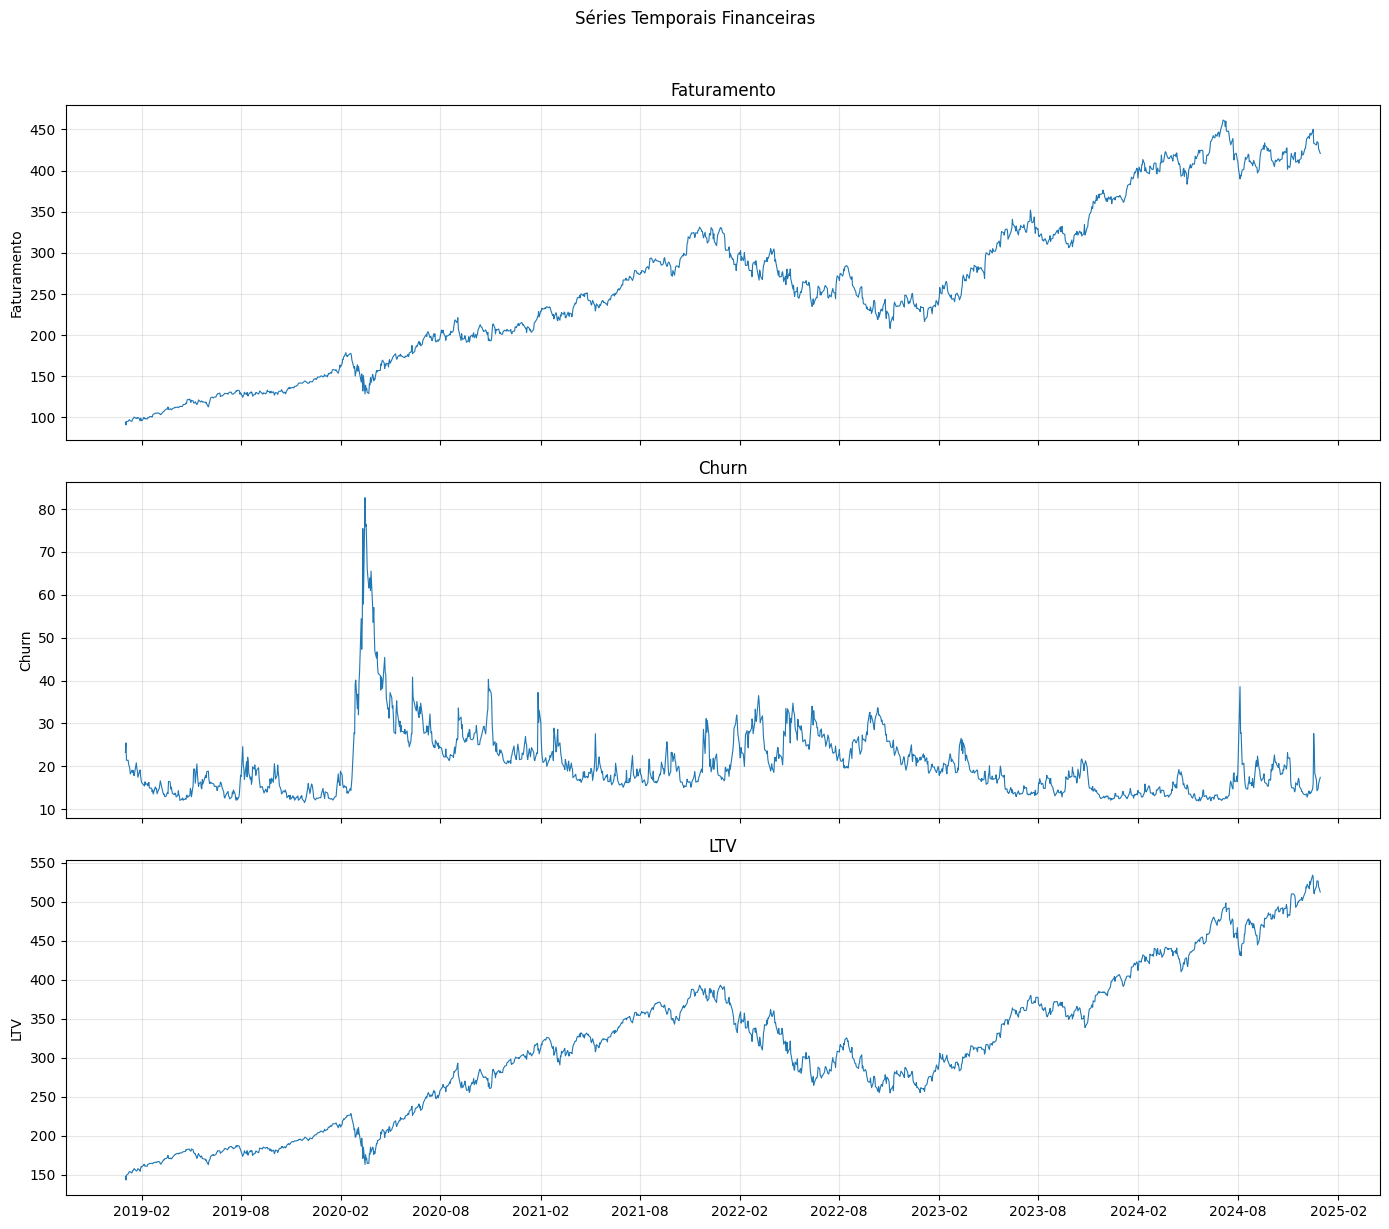

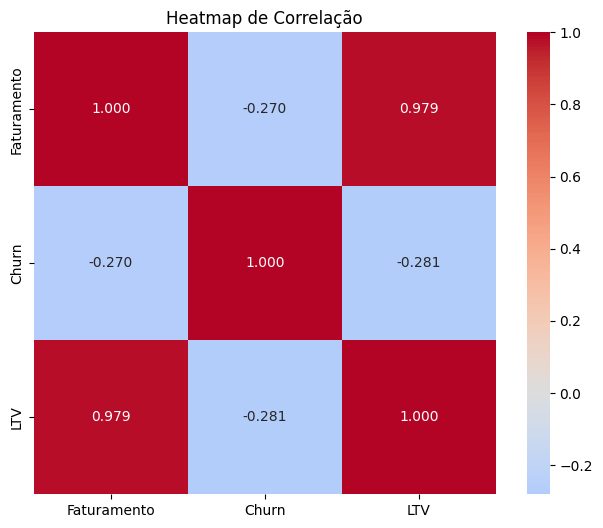

Matriz de correlação:


,Faturamento,Churn,LTV
Faturamento,1.000,-0.270,0.979
Churn,-0.270,1.000,-0.281
LTV,0.979,-0.281,1.000


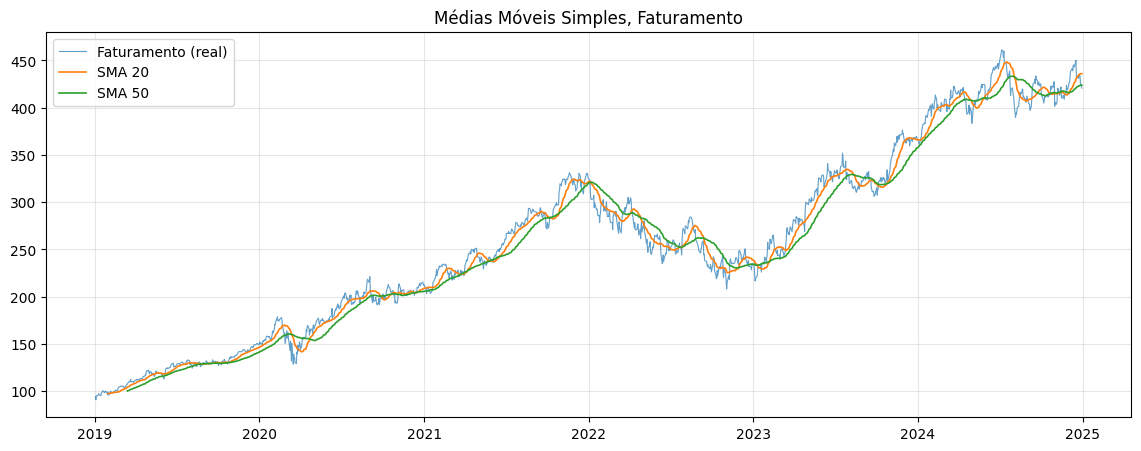

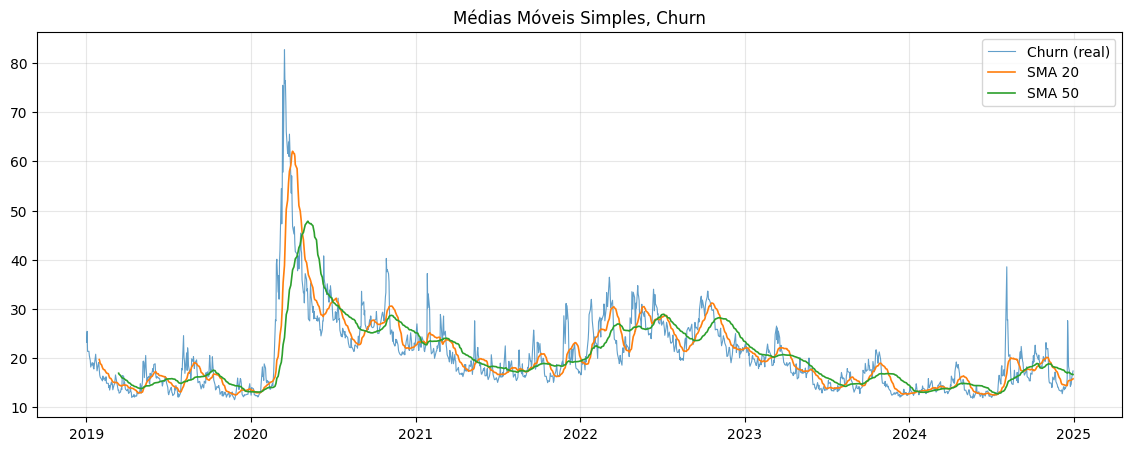

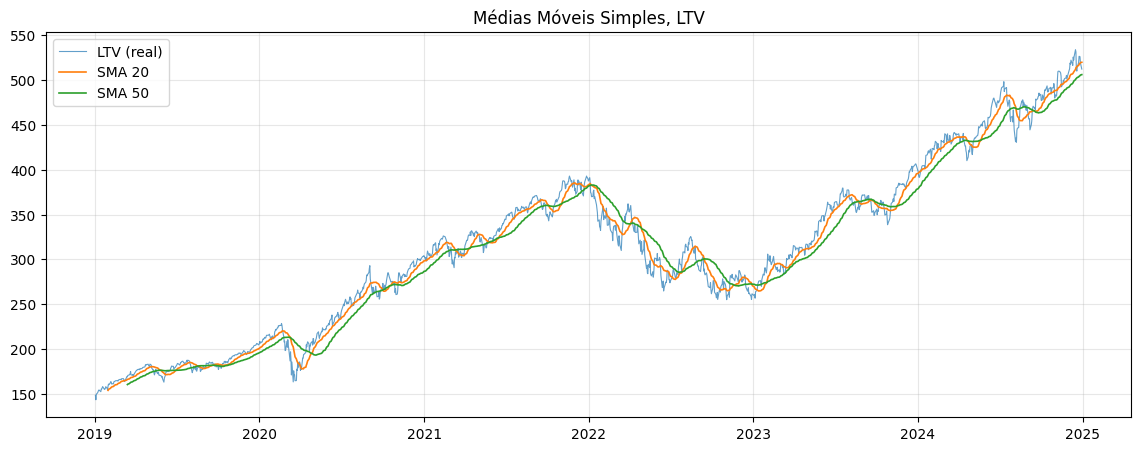

In [22]:
METRICS = list(TICKERS.keys())

plot_time_series(raw_df, METRICS, title="Séries Temporais Financeiras")
corr_matrix = plot_correlation_heatmap(raw_df, METRICS)

print("Matriz de correlação:")
display(corr_matrix.round(3))

for col in METRICS:
    plot_sma(raw_df, col, windows=[20, 50])

## 24. Treinamento e avaliação de cada métrica


Processando métrica: Faturamento


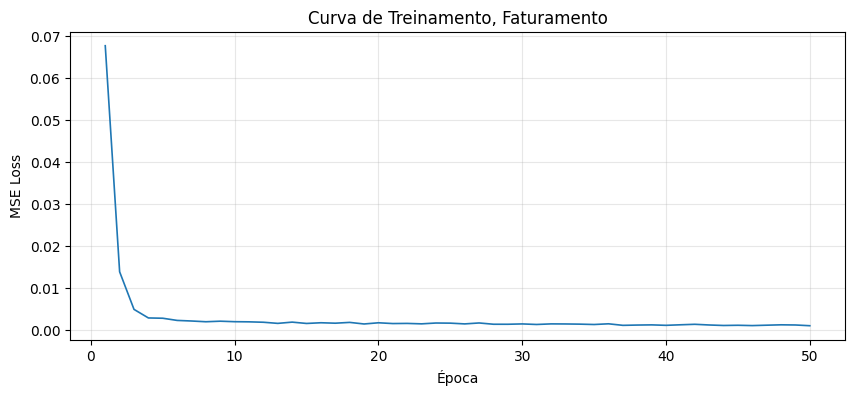

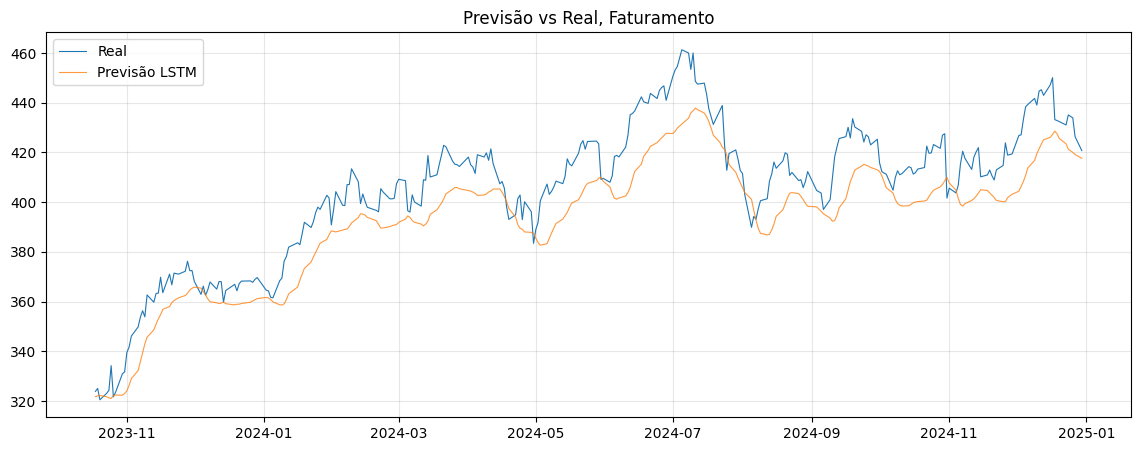

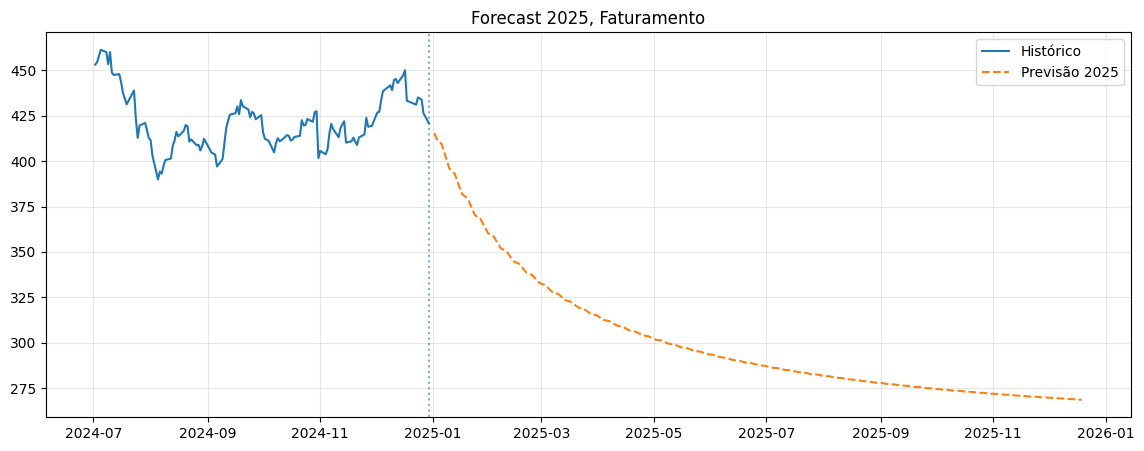

RMSE: 14.38
MAE: 12.53
Variação projetada para 2025: -36.17%

Processando métrica: Churn


In [ ]:
results = {}

for metric in METRICS:
    print(f"\n{'='*60}")
    print(f"Processando métrica: {metric}")
    print(f"{'='*60}")

    data = norm_df[metric].values

    train_loader, test_loader, split_idx = create_dataloaders(data)
    model, losses = train_model(train_loader)

    preds_norm, actuals_norm = evaluate_model(model, test_loader)

    scaler = scalers[metric]
    preds_real = scaler.inverse_transform(preds_norm.reshape(-1, 1)).flatten()
    actuals_real = scaler.inverse_transform(actuals_norm.reshape(-1, 1)).flatten()

    metrics_eval = compute_metrics(preds_real, actuals_real)

    plot_loss_curve(losses, metric_name=metric)

    test_dates = raw_df.index[split_idx:]
    test_dates = test_dates[:len(preds_real)]
    plot_predictions_vs_actual(test_dates, preds_real, actuals_real, metric_name=metric)

    last_window = data[-WINDOW_SIZE:]
    forecast_norm = forecast_future(model, last_window, steps=252)
    forecast_real = scaler.inverse_transform(forecast_norm.reshape(-1, 1)).flatten()
    forecast_dates = pd.bdate_range(start="2025-01-02", periods=252)

    plot_forecast_2025(
        historical_dates=raw_df.index,
        historical_values=raw_df[metric].values,
        forecast_dates=forecast_dates,
        forecast_values=forecast_real,
        metric_name=metric
    )

    start_value = raw_df[metric].values[-1]
    end_value = forecast_real[-1]
    variation_pct = ((end_value - start_value) / start_value) * 100

    results[metric] = {
        "RMSE": metrics_eval["RMSE"],
        "MAE": metrics_eval["MAE"],
        "Último valor histórico": start_value,
        "Último valor previsto": end_value,
        "Variação % 2025": variation_pct
    }

    print(f"RMSE: {metrics_eval['RMSE']:.2f}")
    print(f"MAE: {metrics_eval['MAE']:.2f}")
    print(f"Variação projetada para 2025: {variation_pct:.2f}%")

## 25. Resumo consolidado dos resultados

In [ ]:
results_df = pd.DataFrame(results).T
display(results_df.round(2))

## 26. Interpretação das correlações

### Faturamento x LTV
A correlação muito forte e positiva indica que essas duas métricas caminham quase juntas.

### Churn x Faturamento
A correlação negativa indica que, em cenários de maior medo e incerteza, o faturamento tende a sofrer pressão.

### Churn x LTV
Também existe correlação negativa, mostrando que ambientes mais instáveis reduzem a percepção de valor de longo prazo.